In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [20]:
from importlib import reload
import functions_kde_js
import clustering_functions
reload(functions_kde_js)
reload(clustering_functions)
from seed_fix import set_seeds

from functions_kde_js import (compute_joint_kdes, compute_js_divergence, categorize_count, cluster_similarity_analysis,
                              compute_js_divergence_mD, create_months,
                              read_scale_monthly_kde_mD, read_scale_monthly_kde, create_joint_similarity_matrix, find_mlcv_bandwidth, run_md_sensitivity_analysis, run_cluster_threshold_sensitivity, fit_cluster_kdes_with_mlcv_bandwidth)
from my_imports import pd, np, plt, sns, StandardScaler, plot1_params
from clustering_functions import load_scale_filter_data, clustering_process, run_dynamic_clustering
set_seeds()
plot1_params()

In [3]:
import pytz

In [ ]:
results = run_md_sensitivity_analysis(
    global_start_date="01-2023",
    global_end_date="01-2025",
    plot=True
)

In [4]:
state = run_dynamic_clustering(
    global_start_date="01-2023",
    global_end_date="01-2025",
    metric="silhouette",
    js_lim_month=0.18,
    js_lim_cluster=0.18,
)

current_month_pair: 01-2023 02-2023
Analyzing first month in the data.
6, Number of Optimal Clusters for Month 01-2023
current_month_pair: 02-2023 03-2023
02-2023 is similar to reference month 01-2023. JS mD = 0.11891
current_month_pair: 03-2023 04-2023
03-2023 is similar to reference month 01-2023. JS mD = 0.13048
current_month_pair: 04-2023 05-2023
04-2023 is a new pattern. JS mD = 0.22498, threshold = 0.18
7, Number of Optimal Clusters for Month 04-2023
current_month_pair: 05-2023 06-2023
05-2023 is similar to reference month 04-2023. JS mD = 0.09287
current_month_pair: 06-2023 07-2023
06-2023 is similar to reference month 04-2023. JS mD = 0.09981
current_month_pair: 07-2023 08-2023
07-2023 is similar to reference month 04-2023. JS mD = 0.13361
current_month_pair: 08-2023 09-2023
08-2023 is similar to reference month 04-2023. JS mD = 0.09503
current_month_pair: 09-2023 10-2023
09-2023 is similar to reference month 04-2023. JS mD = 0.10564
current_month_pair: 10-2023 11-2023
10-2023 

In [5]:
cluster_objects_pool = state["cluster_objects_pool"]
monthly_kde = state["monthly_kde"]
monthly_kde_mD = state["monthly_kde_mD"]
cluster_kdes = state["cluster_kdes"]

stream_order = state["stream_order"]
kmeans_objects_dict = state["kmeans_objects_dict"]
similarity_matrix = state["similarity_matrix"]

js_per_feature_mat = state["js_per_feature_mat"]
js_mat_time_order = state["js_mat_time_order"]
js_md_per_month = state["js_md_per_month"]

all_monthly_kde = state["all_monthly_kde"]
all_clusters_kde = state["all_clusters_kde"]

In [ ]:
results = run_cluster_threshold_sensitivity(
    all_clusters_kde=all_clusters_kde,
    plot=True
)

In [96]:
import plot_function_results
reload(plot_function_results)
from plot_function_results import (drift_plot_v2, styled_step_plot_with_dots, rename_cluster_keys,
                                   compute_relative_popularity, plot_cluster_relative_popularity, plot_feature_kde_changes, apply_new_names, plot_clusters_delay, plot_average_load_and_delay_separate)

In [39]:
plot1_params(fsize1_=12.5, dpi1_=200)

In [7]:
global_start_date="01-2023"
global_end_date="01-2024"

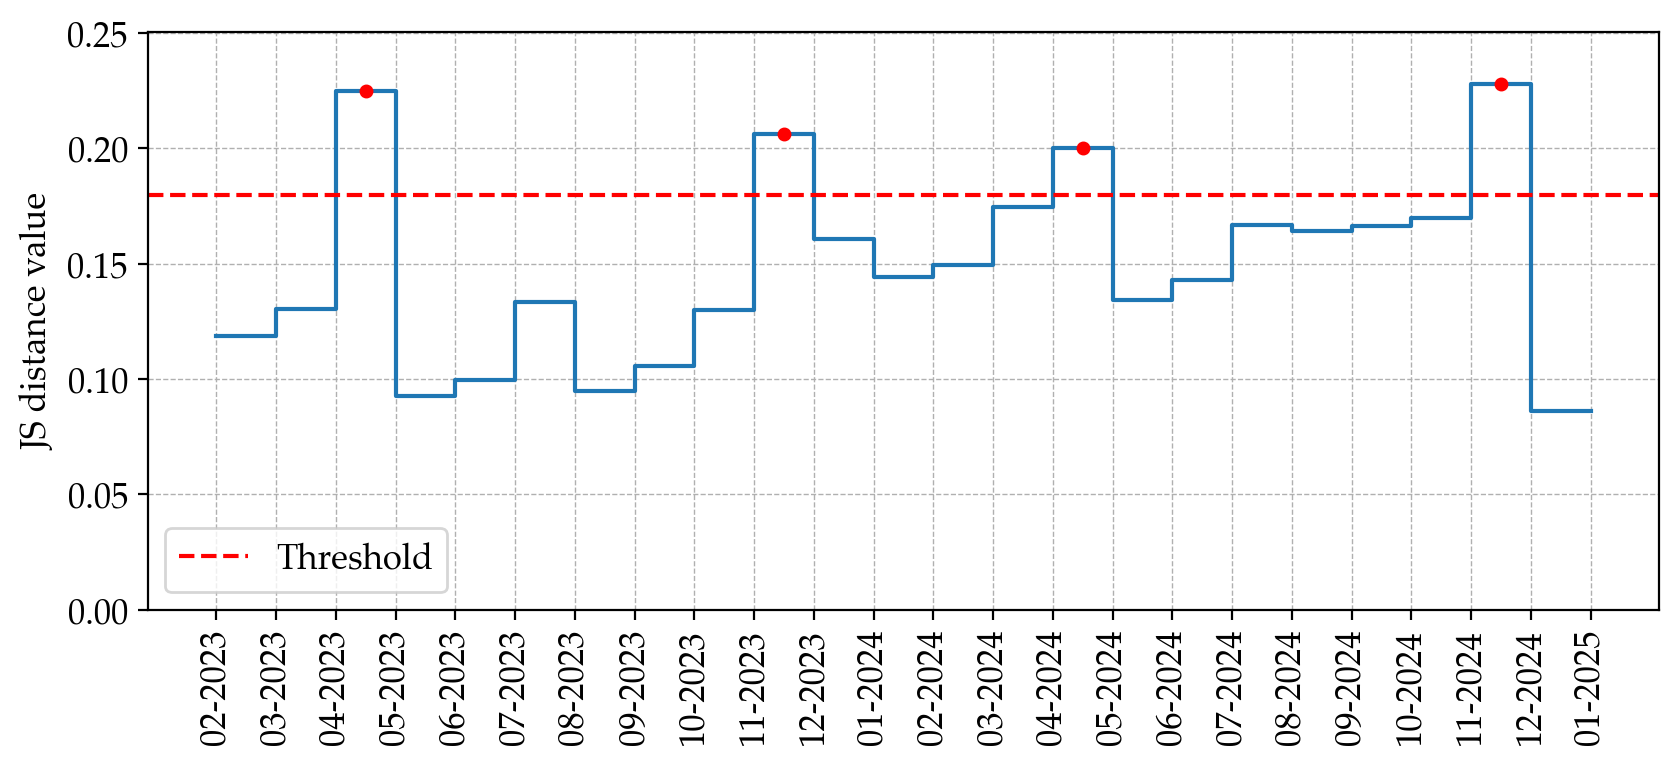

In [33]:
styled_step_plot_with_dots(js_md_per_month)

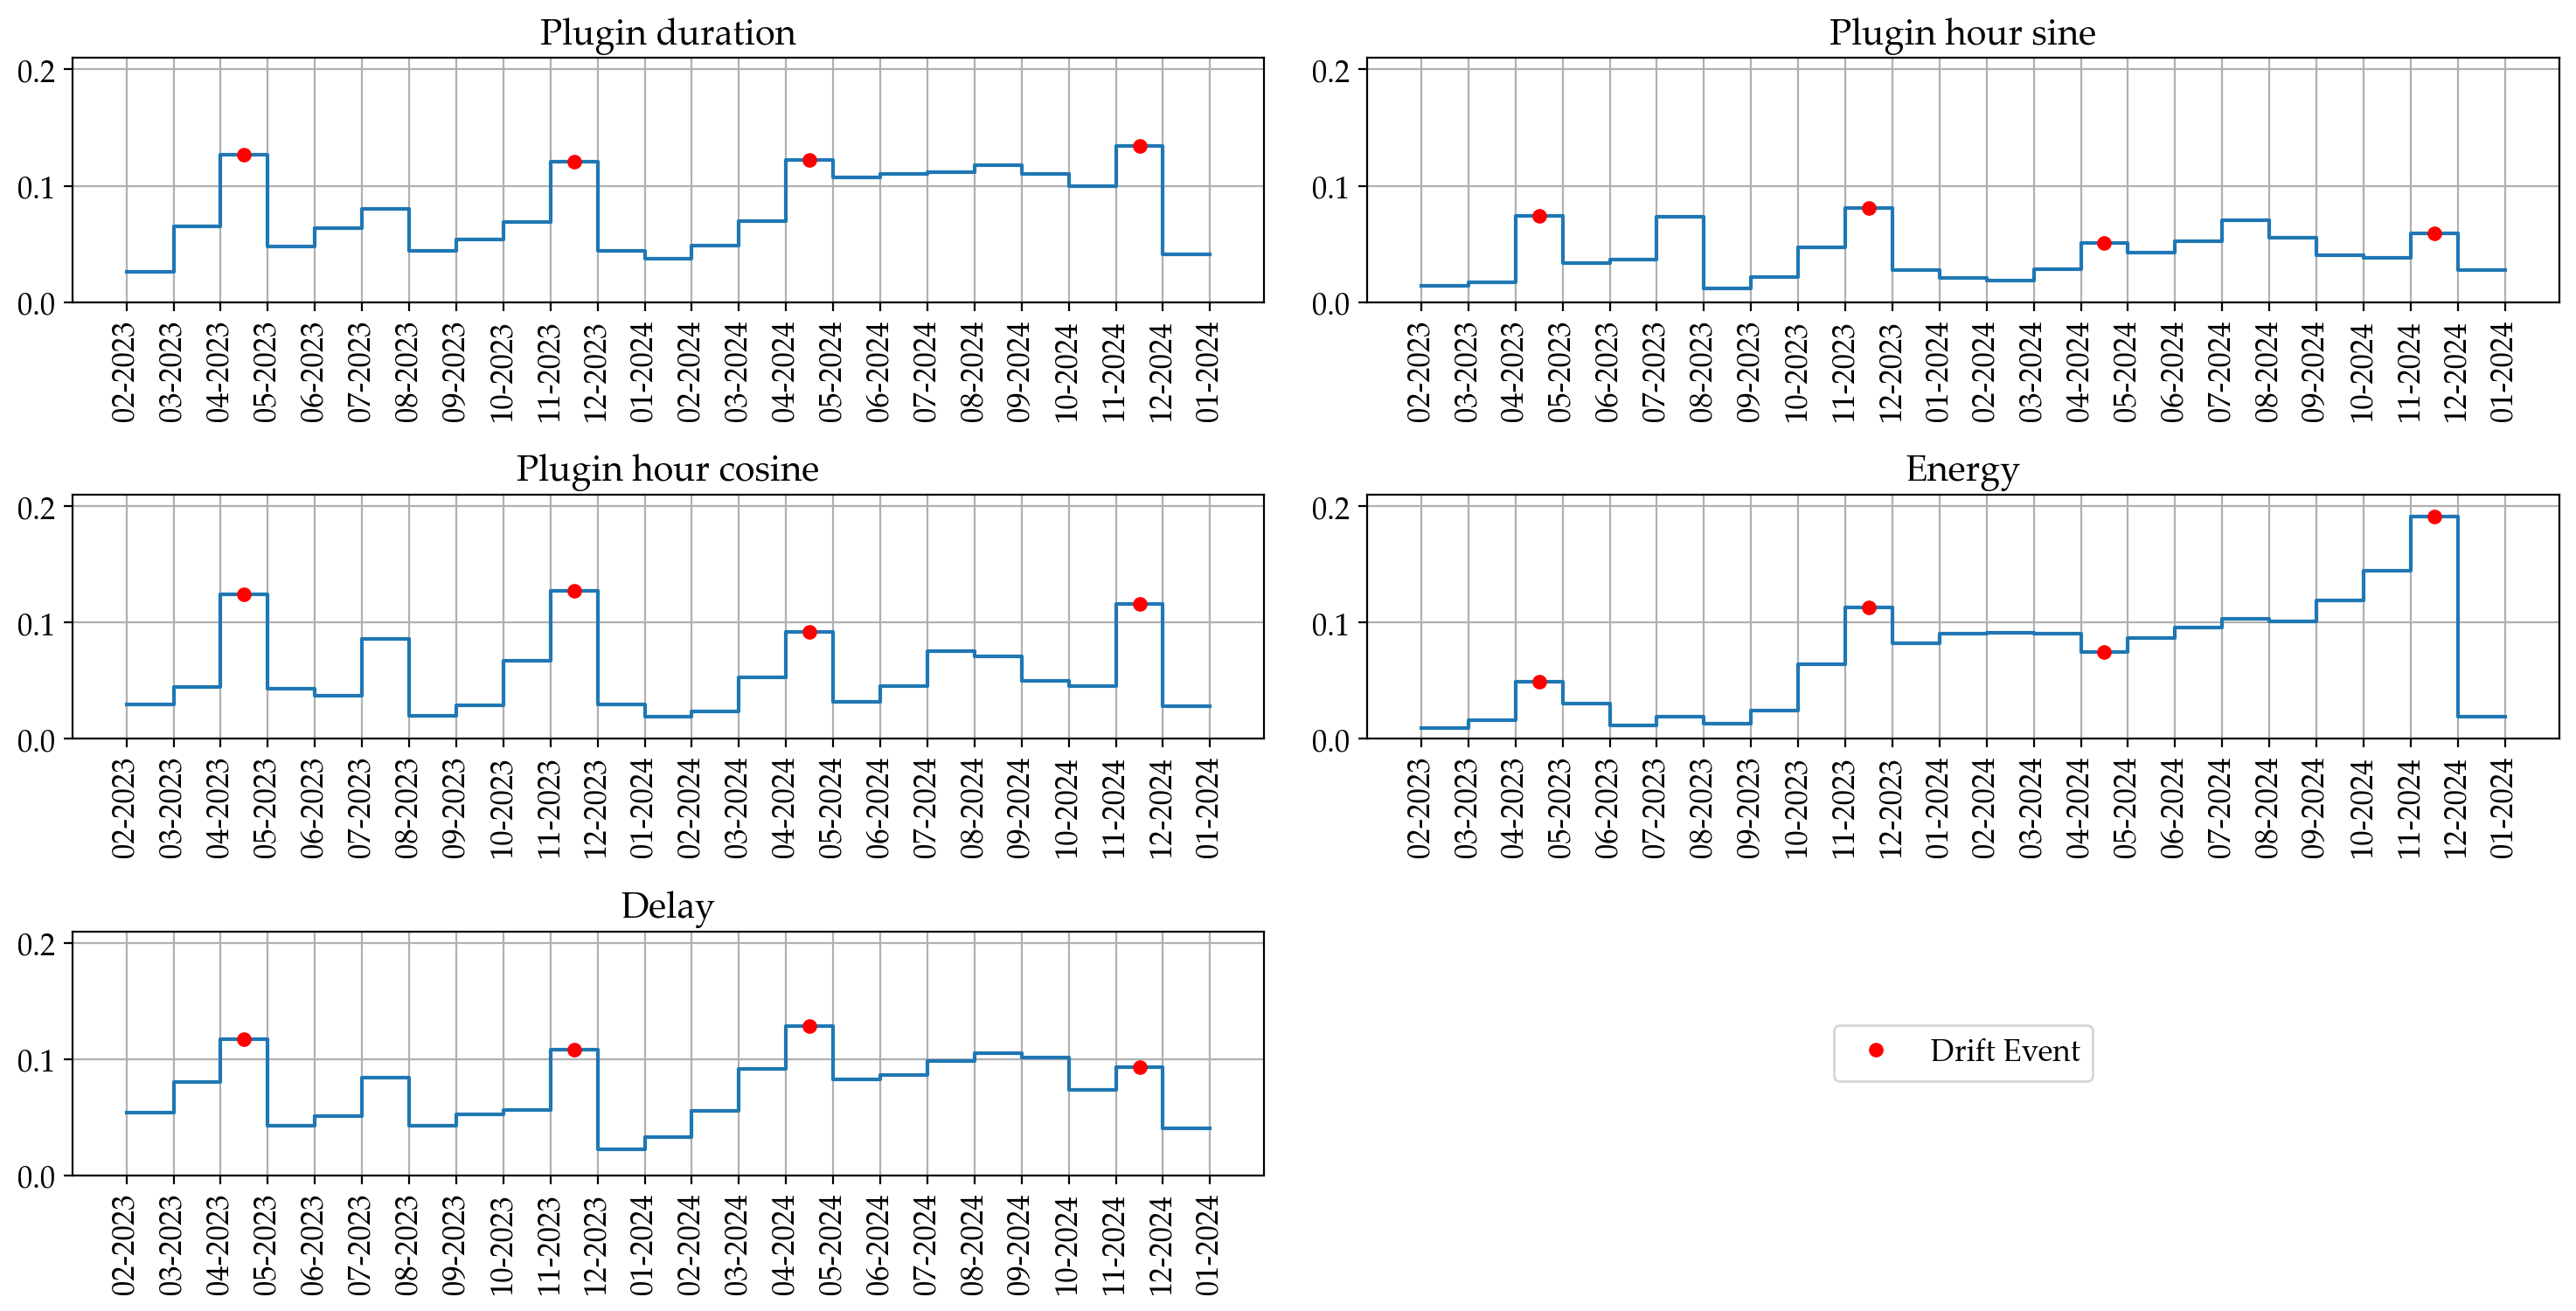

In [34]:
drift_plot_v2(js_per_feature_mat, js_mat_time_order, global_end_date,[2,9,14, 21])

In [25]:
re_ordered_clusters, old_new_tags = rename_cluster_keys(cluster_kdes)

In [45]:
relative_popularity_dict = compute_relative_popularity(re_ordered_clusters)

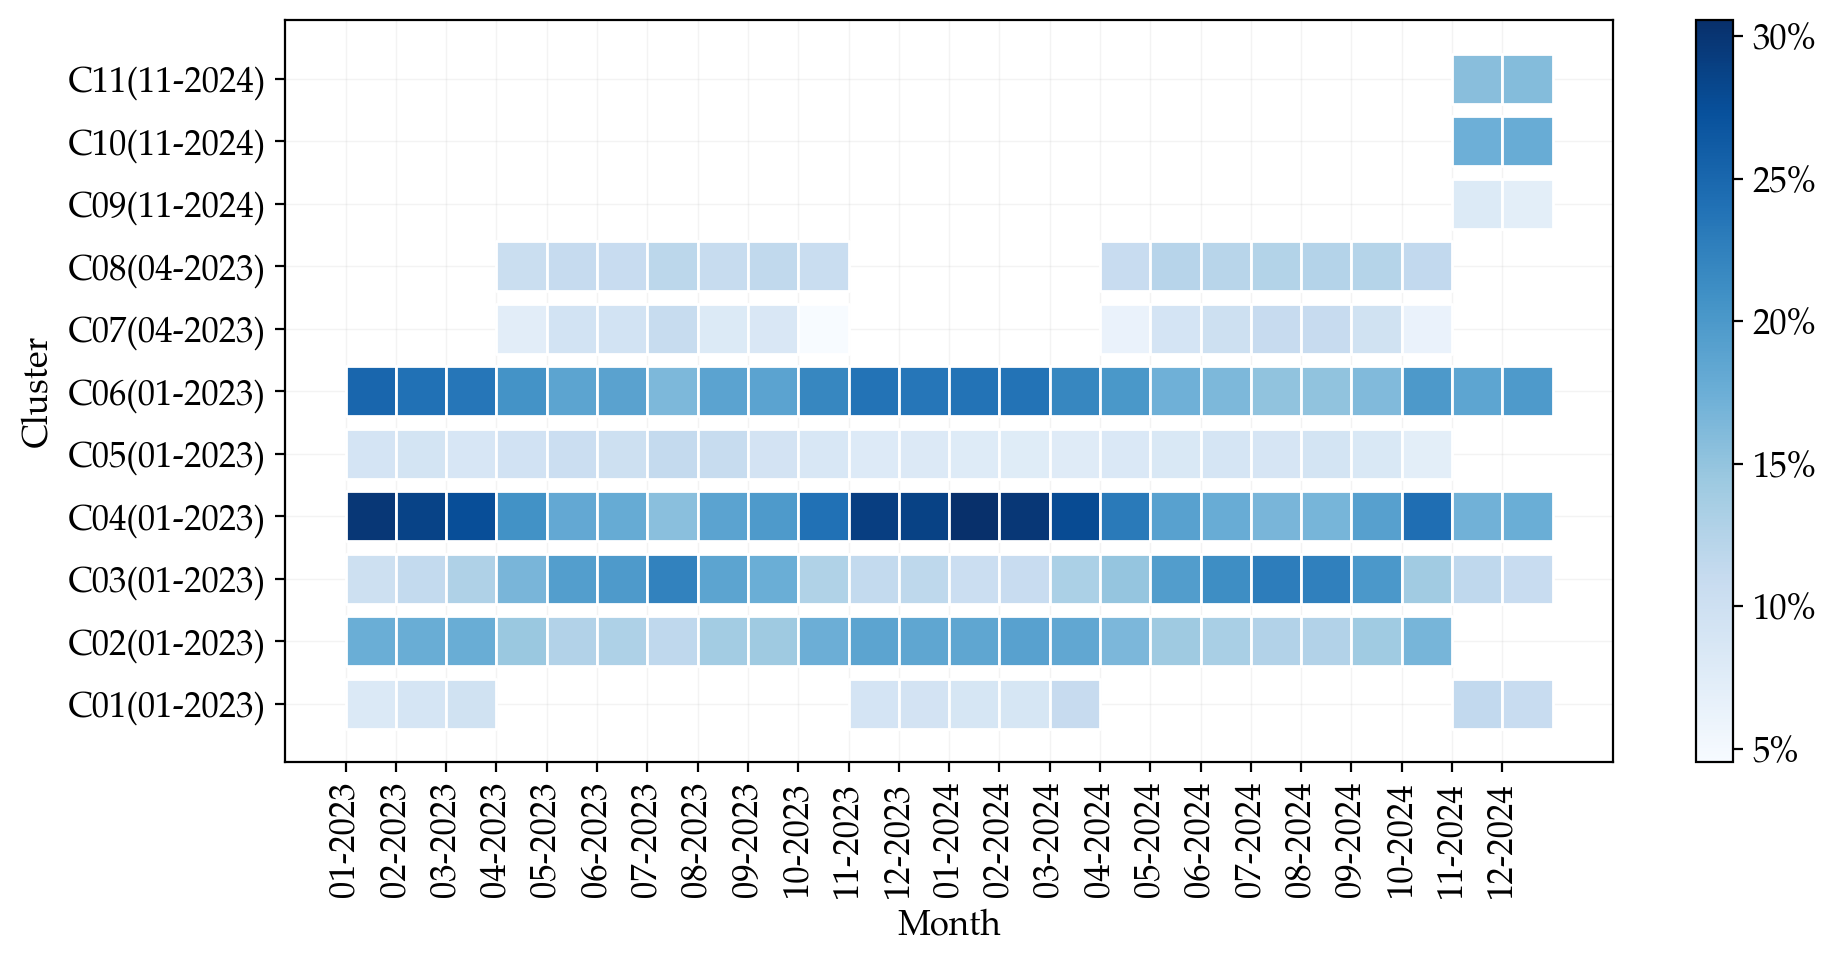

In [51]:
fig, ax, corrected_data, key_old_new = plot_cluster_relative_popularity(
    relative_popularity_dict
)

In [71]:
feature_names = ["Plugin duration", 'Plugin hour sine', "Plugin hour cosine", 'Energy', 'Delay']

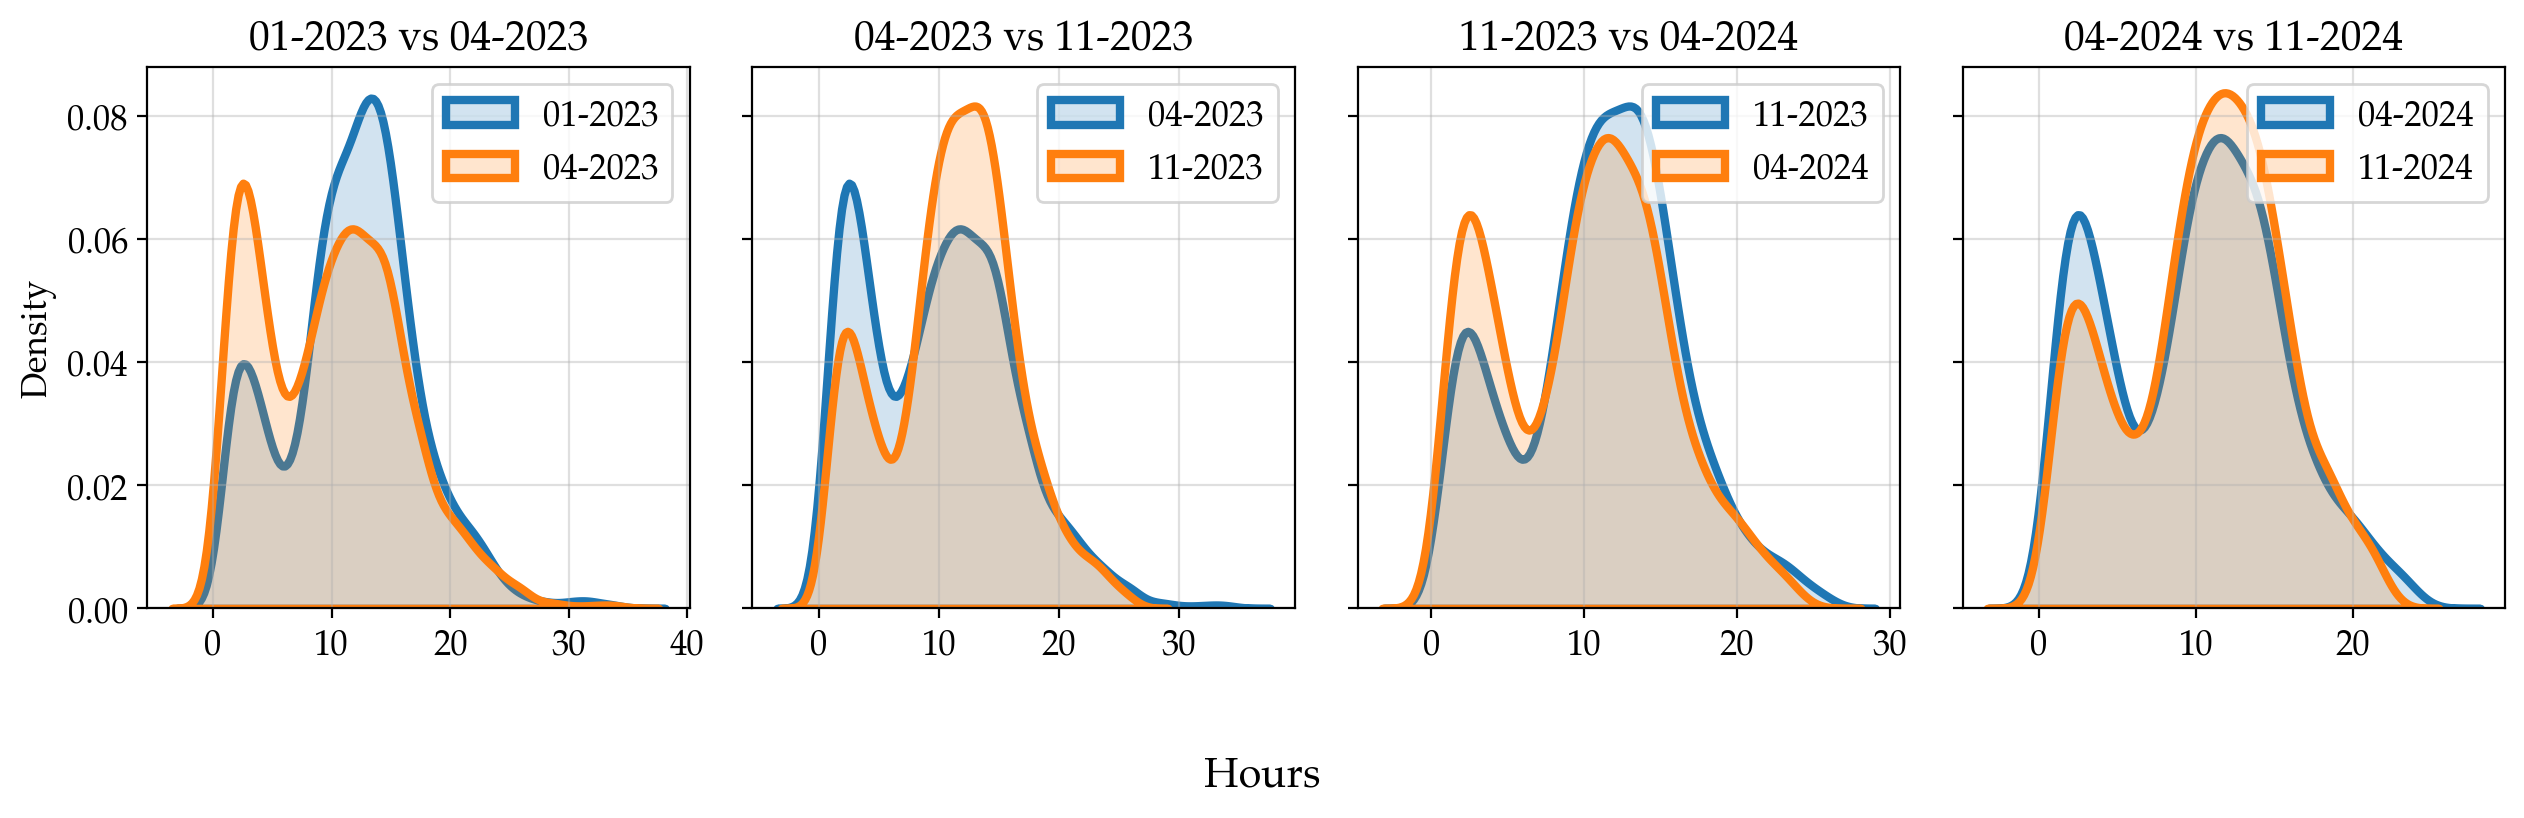

In [74]:
plot_feature_kde_changes(
    feature_name="Plugin duration",
    feature_names=feature_names,
    js_per_feature_mat=js_per_feature_mat,
    js_mat_time_order=js_mat_time_order,
    all_monthly_kde=all_monthly_kde,
    scaler=state["scaler"],
    months_to_compare=[
        "01-2023",
        "04-2023",
        "11-2023",
        "04-2024",
        "11-2024",
    ],
)

In [77]:
cluster_objects_pool = apply_new_names(cluster_objects_pool, old_new_tags)
cluster_objects_pool = apply_new_names(cluster_objects_pool, key_old_new)

In [79]:
subset_dict = dict(list(cluster_objects_pool.items())[0:6])

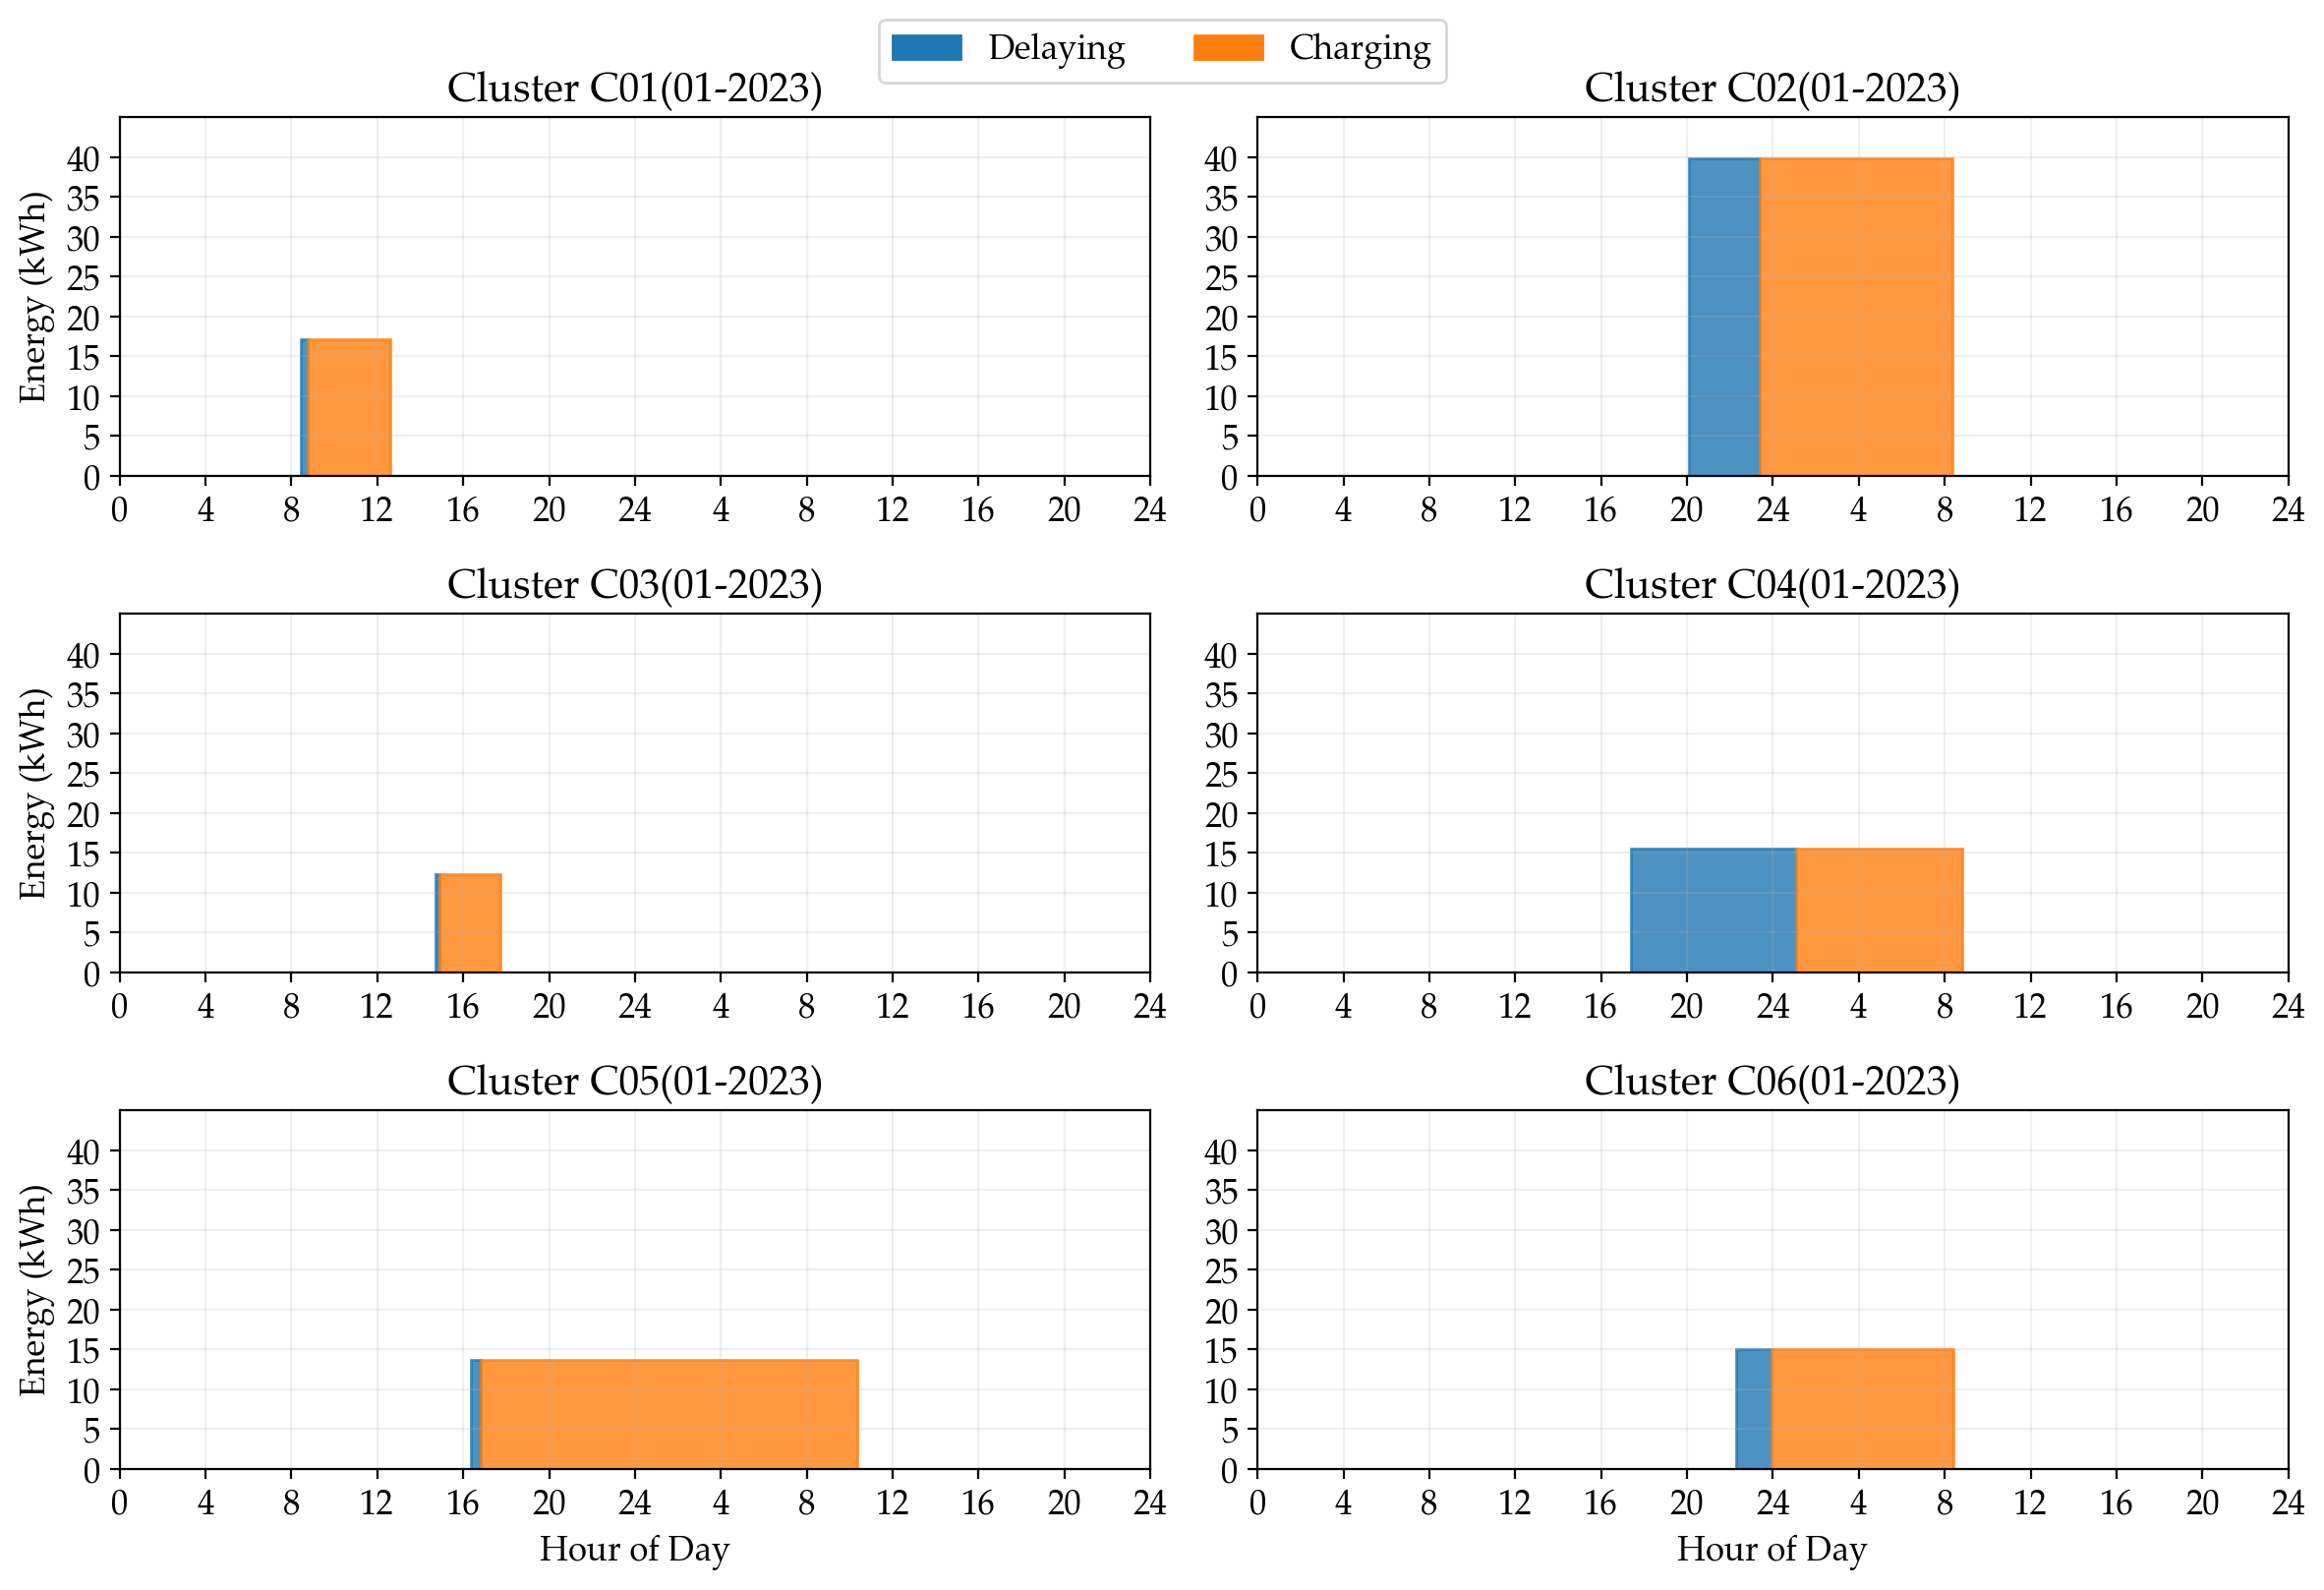

In [89]:
features = ['plugin_duration', 'plugin_hour_sine', 'plugin_hour_cosine', 'energy', 'delay']
df_ct = plot_clusters_delay(subset_dict, scaler, features)

Joint average delay: 3.30 h
Joint median delay:  3.33 h
C02(01-2023) average delay: 3.30 h


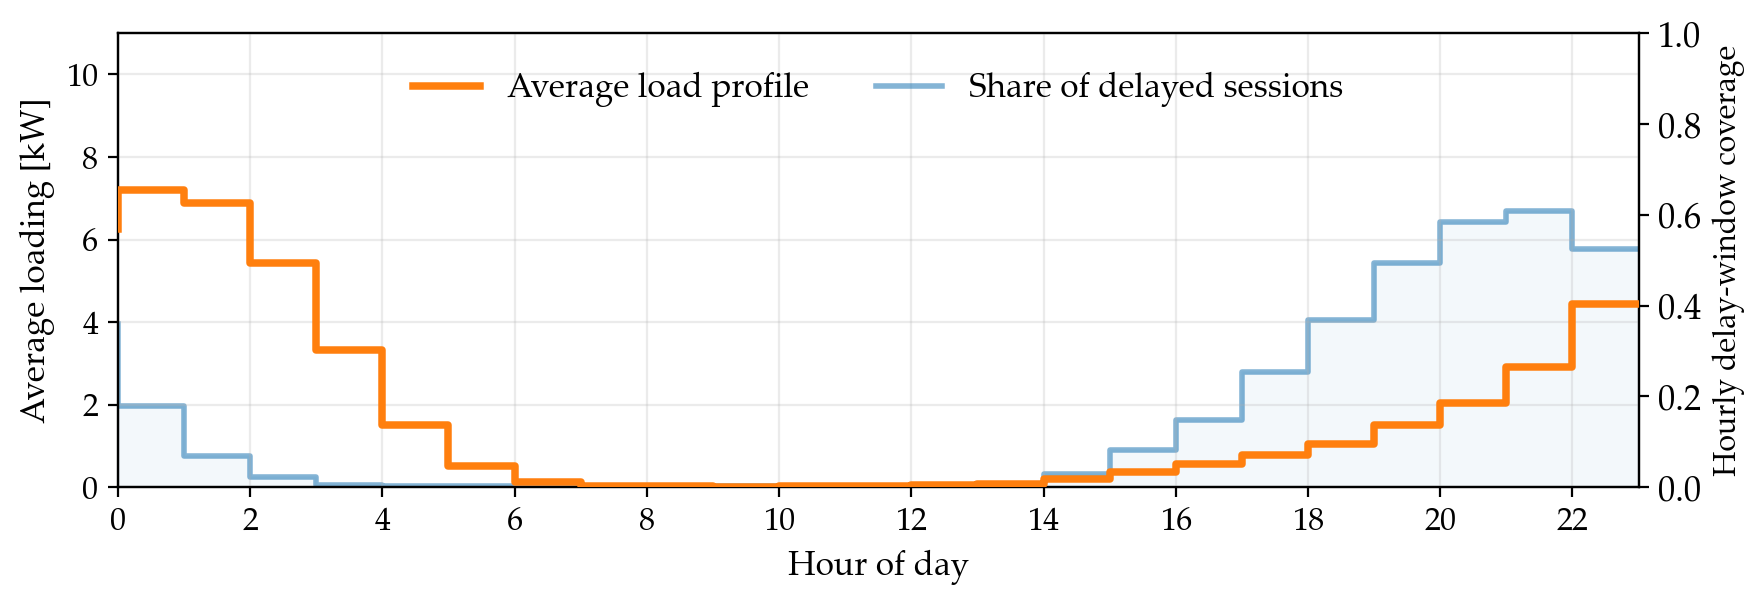

In [97]:
cluster_names = [
     'C02(01-2023)',

]

cluster_weights = {
     'C02(01-2023)': 1,

}
load_profile, delay_profile, df_joint = plot_average_load_and_delay_separate(
    kdes=cluster_objects_pool,
    cluster_names=cluster_names,
    scaler=scaler,
    cluster_weights=cluster_weights,
    n_samples_per_cluster=5000,
    random_state=42,
    kwh_per_hour=11,

)